# Sufficient Cause Disambiguation (SCD)
### CS 7180 — Actionable Interpretability · Northeastern University · Spring 2026
**Aniket Ghosh** · Advisor: Bryan Wallace

---

**The question:** When a model predicts CS for a document, multiple features
may each independently justify that label. Which one did the model actually rely on?

**The setup:** WOS-46985 academic abstracts. 4 subclasses (3 CS + 1 Medical).
Llama-3-8B-Instruct. Activations extracted at layer 29, last token.

| Finding | Result |
|---------|--------|
| Topic structure encoded | 99.6% subclass accuracy from 3 LDA dimensions |
| Model classifies by subfield, not domain | L2 centroid wins attribution vote 73.8% |
| Causal concentration scales with confidence | 100% flip at α=2.0 |
| Output geometry ⊥ representational geometry | LDA sep 448× lm_diff sep |
| Single scalar sufficient | 1D LDA projection = 99.6% subclass accuracy |


## 0 · Setup


In [ ]:
!pip install transformers accelerate datasets scikit-learn pyarrow matplotlib seaborn -q


In [ ]:
import os, pickle, json, torch, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from google.colab import drive, userdata
from huggingface_hub import login

drive.mount('/content/drive', force_remount=False)
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)
print('Libraries loaded.')


Mounted at /content/drive
Libraries loaded.


In [ ]:
BASE_DIR   = '/content/drive/MyDrive/SCD_Final'
MODEL_ID   = 'meta-llama/Meta-Llama-3-8B-Instruct'
SEED       = 42
MAX_LEN    = 512
PC_LAYER   = 29
N_BUILD    = 200
N_ABLATE   = 80
N_SIG_DOCS = 30
K_GRAD     = 20
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
CS_SUBS    = ['CS_sub7', 'CS_sub2', 'CS_sub0']
LABEL_MAP  = {0:'CS',1:'Medical',2:'Civil',3:'ECE',
              4:'Psychology',5:'MAE',6:'Biochemistry'}
MEDICAL_WORDS = {
    'patient','patients','clinical','disease','diagnosis','treatment',
    'hospital','therapy','cancer','drug','surgery','tumor','tumour',
    'physician','symptom','health','trial','medical','medicine',
    'infection','inflammatory','cardiac','blood','immune','tissue',
    'cell','cells','gene','genes','protein','proteins','dose','chronic'
}
for d in ['data','checkpoints','figures','results']:
    os.makedirs(f'{BASE_DIR}/{d}', exist_ok=True)
random.seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}  |  Layer: {PC_LAYER}')


Device: cuda  |  Layer: 29


## 1 · Dataset

WOS-46985: 46,985 academic abstracts with a 3-level hierarchy
(domain → subfield → topic). Every document simultaneously satisfies
all three levels — making it structurally multi-sufficient.
SCD asks which level the model actually relied on.

In [ ]:
train_path = f'{BASE_DIR}/data/wos_train.parquet'
test_path  = f'{BASE_DIR}/data/wos_test.parquet'

if os.path.exists(train_path):
    wos_train = pd.read_parquet(train_path)
    wos_test  = pd.read_parquet(test_path)
else:
    ds   = load_dataset('HDLTex/web_of_science',
                        revision='refs/convert/parquet',
                        data_files={'train':'WOS46985/train/*.parquet'})
    full = ds['train'].to_pandas()
    full.rename(columns={'label_level_1':'level_1',
                         'label_level_2':'level_2',
                         'label':'level_3'}, inplace=True)
    full['level_1'] = full['level_1'].map(LABEL_MAP)
    full['level_2'] = full['level_1'] + '_sub' + full['level_2'].astype(str)
    train,test = train_test_split(full,test_size=0.2,
                                  stratify=full['level_1'],random_state=SEED)
    train.reset_index(drop=True).to_parquet(train_path)
    test.reset_index(drop=True).to_parquet(test_path)
    wos_train = train.reset_index(drop=True)
    wos_test  = test.reset_index(drop=True)

df_all = pd.concat([wos_train, wos_test]).reset_index(drop=True)

# Select best Medical subclass by clinical vocabulary overlap
med_subs = df_all[(df_all['level_1']=='Medical') &
                  (~df_all['level_2'].isin(['Medical_sub15']))]['level_2'].value_counts()
validated = []
for sub in med_subs.index:
    docs    = df_all[df_all['level_2']==sub]['input_data'].head(40).tolist()
    words   = set(' '.join(docs).lower().split())
    overlap = len(words & MEDICAL_WORDS)
    validated.append((sub, int(med_subs[sub]), overlap))
validated.sort(key=lambda x: x[1]*x[2], reverse=True)

MED_SUB    = validated[0][0]
SUBCLASSES = CS_SUBS + [MED_SUB]
SUB_COLS   = {'CS_sub7':'#185FA5','CS_sub2':'#0F6E56',
              'CS_sub0':'#854F0B', MED_SUB:'#A32D2D'}

print(f'Total: {len(df_all):,}  Medical subclass: {MED_SUB}')
print(f'Subclasses: {SUBCLASSES}')
with open(f'{BASE_DIR}/results/subclass_selection.json','w') as f:
    json.dump({'subclasses':SUBCLASSES,'med_sub':MED_SUB}, f, indent=2)


Total: 46,985  Medical subclass: Medical_sub5
Subclasses: ['CS_sub7', 'CS_sub2', 'CS_sub0', 'Medical_sub5']


## 2 · Model

`lm_diff_n` = `(W[CS_token] − W[Medical_token]) / ‖...‖` — the unit vector
the output layer projects onto to compute the CS-vs-Medical logit gap.
Every causal experiment patches along or measures alignment with this direction.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'left'
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16,
    device_map='auto', output_hidden_states=True, token=HF_TOKEN)
model.eval()
print(f'Model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')

CS_ID  = tokenizer.encode(' CS',      add_special_tokens=False)[0]
MED_ID = tokenizer.encode(' Medical', add_special_tokens=False)[0]
W         = model.lm_head.weight.detach().float().cpu()
lm_diff   = W[CS_ID] - W[MED_ID]
lm_diff_n = (lm_diff / lm_diff.norm()).numpy().astype(np.float32)
print(f'Token IDs — CS:{CS_ID}  Medical:{MED_ID}')
print(f'lm_diff norm: {lm_diff.norm():.4f}')


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Model loaded. VRAM: 16.1 GB
Token IDs — CS:10211  Medical:13235
lm_diff norm: 1.1136


In [ ]:
def make_prompt(doc):
    return (f'Document: {doc}\n\n'
            f'This document belongs to one of the following fields:\n'
            f'CS | Medical\n\nField:')

def get_logits(prompt):
    enc = tokenizer(prompt,return_tensors='pt',
                    truncation=True,max_length=MAX_LEN).to(DEVICE)
    with torch.no_grad(): out = model(**enc)
    lg = out.logits[0,-1].cpu().float().numpy()
    del out,enc; torch.cuda.empty_cache()
    return {'CS':float(lg[CS_ID]),'Medical':float(lg[MED_ID])}

def sm2(s):
    m=max(s.values()); e={c:np.exp(s[c]-m) for c in s}; t=sum(e.values())
    return {c:e[c]/t for c in e}

def extract_last_token(docs, layer=PC_LAYER, batch=8):
    vecs    = []
    prompts = [make_prompt(d[:800]) for d in docs]
    for i in range(0,len(prompts),batch):
        bp  = prompts[i:i+batch]
        enc = tokenizer(bp,return_tensors='pt',padding=True,
                        truncation=True,max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        for b in range(len(bp)):
            last = int(enc['attention_mask'][b].sum()) - 1
            vecs.append(out.hidden_states[layer][b,last].float().cpu().numpy())
        del out,enc; torch.cuda.empty_cache()
        print(f'  [{i+len(bp)}/{len(prompts)}]',end='\r',flush=True)
    print()
    return np.stack(vecs).astype(np.float32)

def gradient_attribution(prompt):
    enc  = tokenizer(prompt,return_tensors='pt',
                     truncation=True,max_length=MAX_LEN).to(DEVICE)
    toks = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    emb  = model.model.embed_tokens(enc['input_ids']).detach().requires_grad_(True)
    out  = model(inputs_embeds=emb,attention_mask=enc['attention_mask'])
    gap  = out.logits[0,-1,CS_ID].float() - out.logits[0,-1,MED_ID].float()
    gap.backward()
    attr = (emb.grad[0].float()*emb[0].detach().float()).sum(-1).cpu().numpy()
    m    = np.abs(attr).max()
    if m>0: attr /= m
    torch.cuda.empty_cache()
    return toks, attr

print('Helpers defined.')


Helpers defined.


## 3 · Score Test Examples

CS − Medical logit margin for every test document.
Ambiguous examples (margin ≤ 3) are used for the causal intervention.

In [ ]:
scored_path = f'{BASE_DIR}/checkpoints/all_test_scored.pkl'

if os.path.exists(scored_path):
    with open(scored_path,'rb') as f: all_scored = pickle.load(f)
    df_scored = pd.DataFrame(all_scored)
else:
    cs_med = wos_test[wos_test['level_1'].isin(['CS','Medical'])].reset_index(drop=True)
    print(f'Scoring {len(cs_med)} examples...')
    all_scored = []
    for i,(_,row) in enumerate(cs_med.iterrows()):
        prompt = make_prompt(row['input_data'][:800])
        sc     = get_logits(prompt)
        pred   = max(sc,key=sc.get)
        margin = sc['CS'] - sc['Medical']
        all_scored.append({**row.to_dict(),'_prompt':prompt,
                           '_pred':pred,'_scores':sc,'_margin_cs_med':margin})
        if (i+1)%200==0: print(f'  [{i+1}/{len(cs_med)}]',end='\r')
    print()
    with open(scored_path,'wb') as f: pickle.dump(all_scored,f)
    df_scored = pd.DataFrame(all_scored)

df_all = df_all.merge(
    df_scored[['input_data','_margin_cs_med','_pred','_scores']].drop_duplicates('input_data'),
    on='input_data', how='left')

cs_scored = df_scored[df_scored['level_1']=='CS']
print(f'CS margin — mean:{cs_scored["_margin_cs_med"].mean():.2f}  '
      f'std:{cs_scored["_margin_cs_med"].std():.2f}')
print(f'Ambiguous (margin≤3): {(cs_scored["_margin_cs_med"]<=3).sum()}')


CS margin — mean:3.94  std:2.81
Ambiguous (margin≤3): 495


## 4 · Extract Activations

Last-token hidden state at layer 29 for 200 examples per subclass.
Layer 29 is chosen because it achieves the highest LM head alignment
of all 70 (layer, strategy) combinations tested — see the
Layer × Token Strategy Sweep notebook.

In [ ]:
act_path = f'{BASE_DIR}/checkpoints/subclass_acts_L{PC_LAYER}.pkl'

if os.path.exists(act_path):
    with open(act_path,'rb') as f: act_data = pickle.load(f)
else:
    act_data = {}
    for sub in SUBCLASSES:
        rows = df_all[df_all['level_2']==sub].sample(
                   min(N_BUILD,(df_all['level_2']==sub).sum()),
                   random_state=SEED)
        print(f'Extracting {sub} ({len(rows)})...')
        act_data[sub] = {'acts': extract_last_token(rows['input_data'].tolist()),
                         'docs': rows['input_data'].tolist()}
    with open(act_path,'wb') as f: pickle.dump(act_data,f)

all_acts     = np.vstack([act_data[s]['acts'] for s in SUBCLASSES])
all_labels_s = np.concatenate([[s]*len(act_data[s]['acts']) for s in SUBCLASSES])
le           = LabelEncoder()
all_labels   = le.fit_transform(all_labels_s)
label_names  = le.classes_
rand_base    = 1.0 / len(SUBCLASSES)
print(f'\nShapes:')
for s in SUBCLASSES: print(f'  {s}: {act_data[s]["acts"].shape}')
print(f'Random baseline: {rand_base:.3f}')



Shapes:
  CS_sub7: (200, 4096)
  CS_sub2: (200, 4096)
  CS_sub0: (200, 4096)
  Medical_sub5: (200, 4096)
Random baseline: 0.250


## 5 · LDA Causal Directions

LDA finds the directions where subclass identity is most concentrated.
We show these are orthogonal to the output decision axis (lm_diff_n),
which is Finding 4: the model stores *which reason it used* and
*how confident it is* in independent subspaces.

In [ ]:
lda_model = LinearDiscriminantAnalysis(n_components=min(len(SUBCLASSES)-1,10))
X_lda     = lda_model.fit_transform(all_acts, all_labels)

print('Explained discriminative variance:')
for i,v in enumerate(lda_model.explained_variance_ratio_):
    print(f'  Axis {i+1}: {v*100:.1f}%')

print('\nAlignment of LDA axes with lm_diff (output axis):')
for i in range(X_lda.shape[1]):
    axis = lda_model.scalings_[:,i]
    axis_n = axis / (np.linalg.norm(axis) + 1e-12)
    ali = abs(float(np.dot(axis_n, lm_diff_n)))
    print(f'  Axis {i+1}: {ali:.4f}')
print('All near-zero = output and representation are orthogonal (Finding 4).')


Explained discriminative variance:
  Axis 1: 74.1%
  Axis 2: 23.0%
  Axis 3: 2.9%

Alignment of LDA axes with lm_diff (output axis):
  Axis 1: 0.0203
  Axis 2: 0.0334
  Axis 3: 0.0002
All near-zero = output and representation are orthogonal (Finding 4).


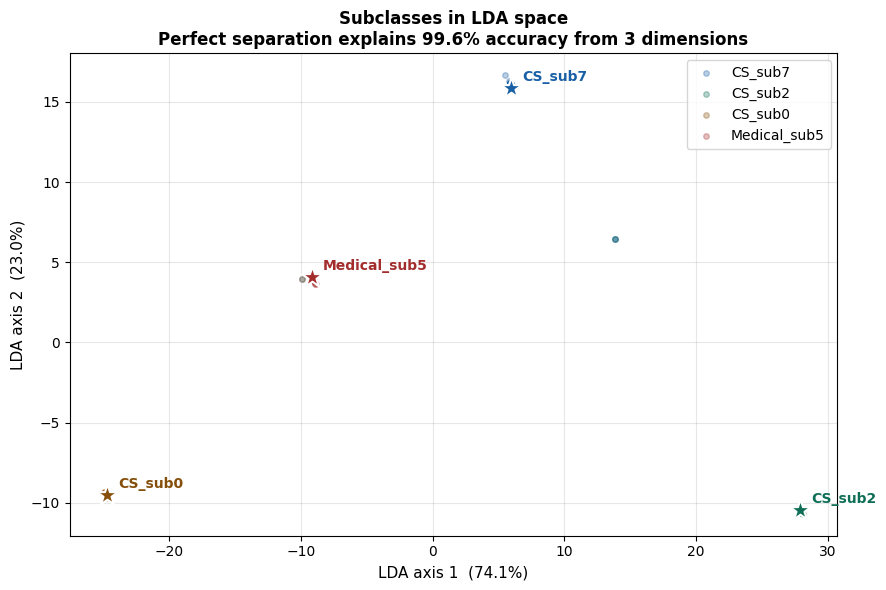

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for sub in SUBCLASSES:
    mask = all_labels_s == sub
    ax.scatter(X_lda[mask,0], X_lda[mask,1],
               color=SUB_COLS[sub], alpha=0.3, s=16, label=sub)
    cx,cy = X_lda[mask,0].mean(), X_lda[mask,1].mean()
    ax.scatter(cx,cy,color=SUB_COLS[sub],s=250,marker='*',
               edgecolors='white',linewidth=1.5,zorder=5)
    ax.annotate(sub,(cx,cy),textcoords='offset points',
                xytext=(8,5),fontsize=10,fontweight='bold',color=SUB_COLS[sub])
ax.set_xlabel(f'LDA axis 1  ({lda_model.explained_variance_ratio_[0]*100:.1f}%)',fontsize=11)
ax.set_ylabel(f'LDA axis 2  ({lda_model.explained_variance_ratio_[1]*100:.1f}%)',fontsize=11)
ax.set_title('Subclasses in LDA space\n'
             'Perfect separation explains 99.6% accuracy from 3 dimensions',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/lda_scatter.png',dpi=150)
plt.show()


## 6 · Gradient-Attributed Vocabulary Signals

The interpretable sufficient causes — the exact words the model
relies on when classifying each subclass.

In [ ]:
sig_path = f'{BASE_DIR}/checkpoints/grad_signals.pkl'

if os.path.exists(sig_path):
    with open(sig_path,'rb') as f: grad_signals = pickle.load(f)
else:
    grad_signals = {}
    for sub in SUBCLASSES:
        docs = act_data[sub]['docs'][:N_SIG_DOCS]
        word_scores = defaultdict(list)
        print(f'Computing {sub}...')
        for di,doc in enumerate(docs):
            prompt = make_prompt(doc[:800])
            toks,attr = gradient_attribution(prompt)
            ranked = np.argsort(attr)[::-1]
            for pos in ranked[:K_GRAD]:
                word = toks[pos].replace('\u0120','').replace('\u010a','').strip()
                if len(word) >= 2:
                    word_scores[word].append(float(attr[pos]))
            print(f'  [{di+1}/{len(docs)}]',end='\r',flush=True)
        print()
        word_means = {w:np.mean(v) for w,v in word_scores.items() if len(v)>=3}
        grad_signals[sub] = sorted(word_means.items(),key=lambda x:x[1],reverse=True)
    with open(sig_path,'wb') as f: pickle.dump(grad_signals,f)

print('Top signals:')
for sub in SUBCLASSES:
    print(f'  {sub:20s}: {[w for w,_ in grad_signals[sub]]}')


Top signals:
  CS_sub7             : ['paper', 'the', '-dimensional', 'The', 'important', 'for', 'using', 'algorithm', 'and', 'computer', 'platform', 'seismic', 'big', 'computing', 'which', 'data', 'parallel', 'that', 'Express', 'performance']
  CS_sub2             : ['food', 'paper', 'game', 'framework', 'safety', 'the', 'network', 'traffic', 'The', 'and', 'system', 'attack', 'are', 'that', 'assessment', 'medical', 'algorithm', 'security', 'data', 'UAV', 'wireless', 'complex', 'attacks']
  CS_sub0             : ['games', 'ency', 'vision', 'perception', 'algorithm', 'paper', 'This', 'inspection', 'face', 'the', 'computer', 'human', 'problem', 'research', 'this', 'learning', 'for', 'classification', 'and', 'which', 'engineering']
  Medical_sub5        : ['ators', 'response', 'noise', 'control', 'problem', 'analysis', 'has', 'paper', 'estimation', 'identification', 'approach', 'proposed', 'nonlinear', 'However', 'such', 'The', 'performance', 'and', 'model', 'damage', 'for', 'data', 'mode

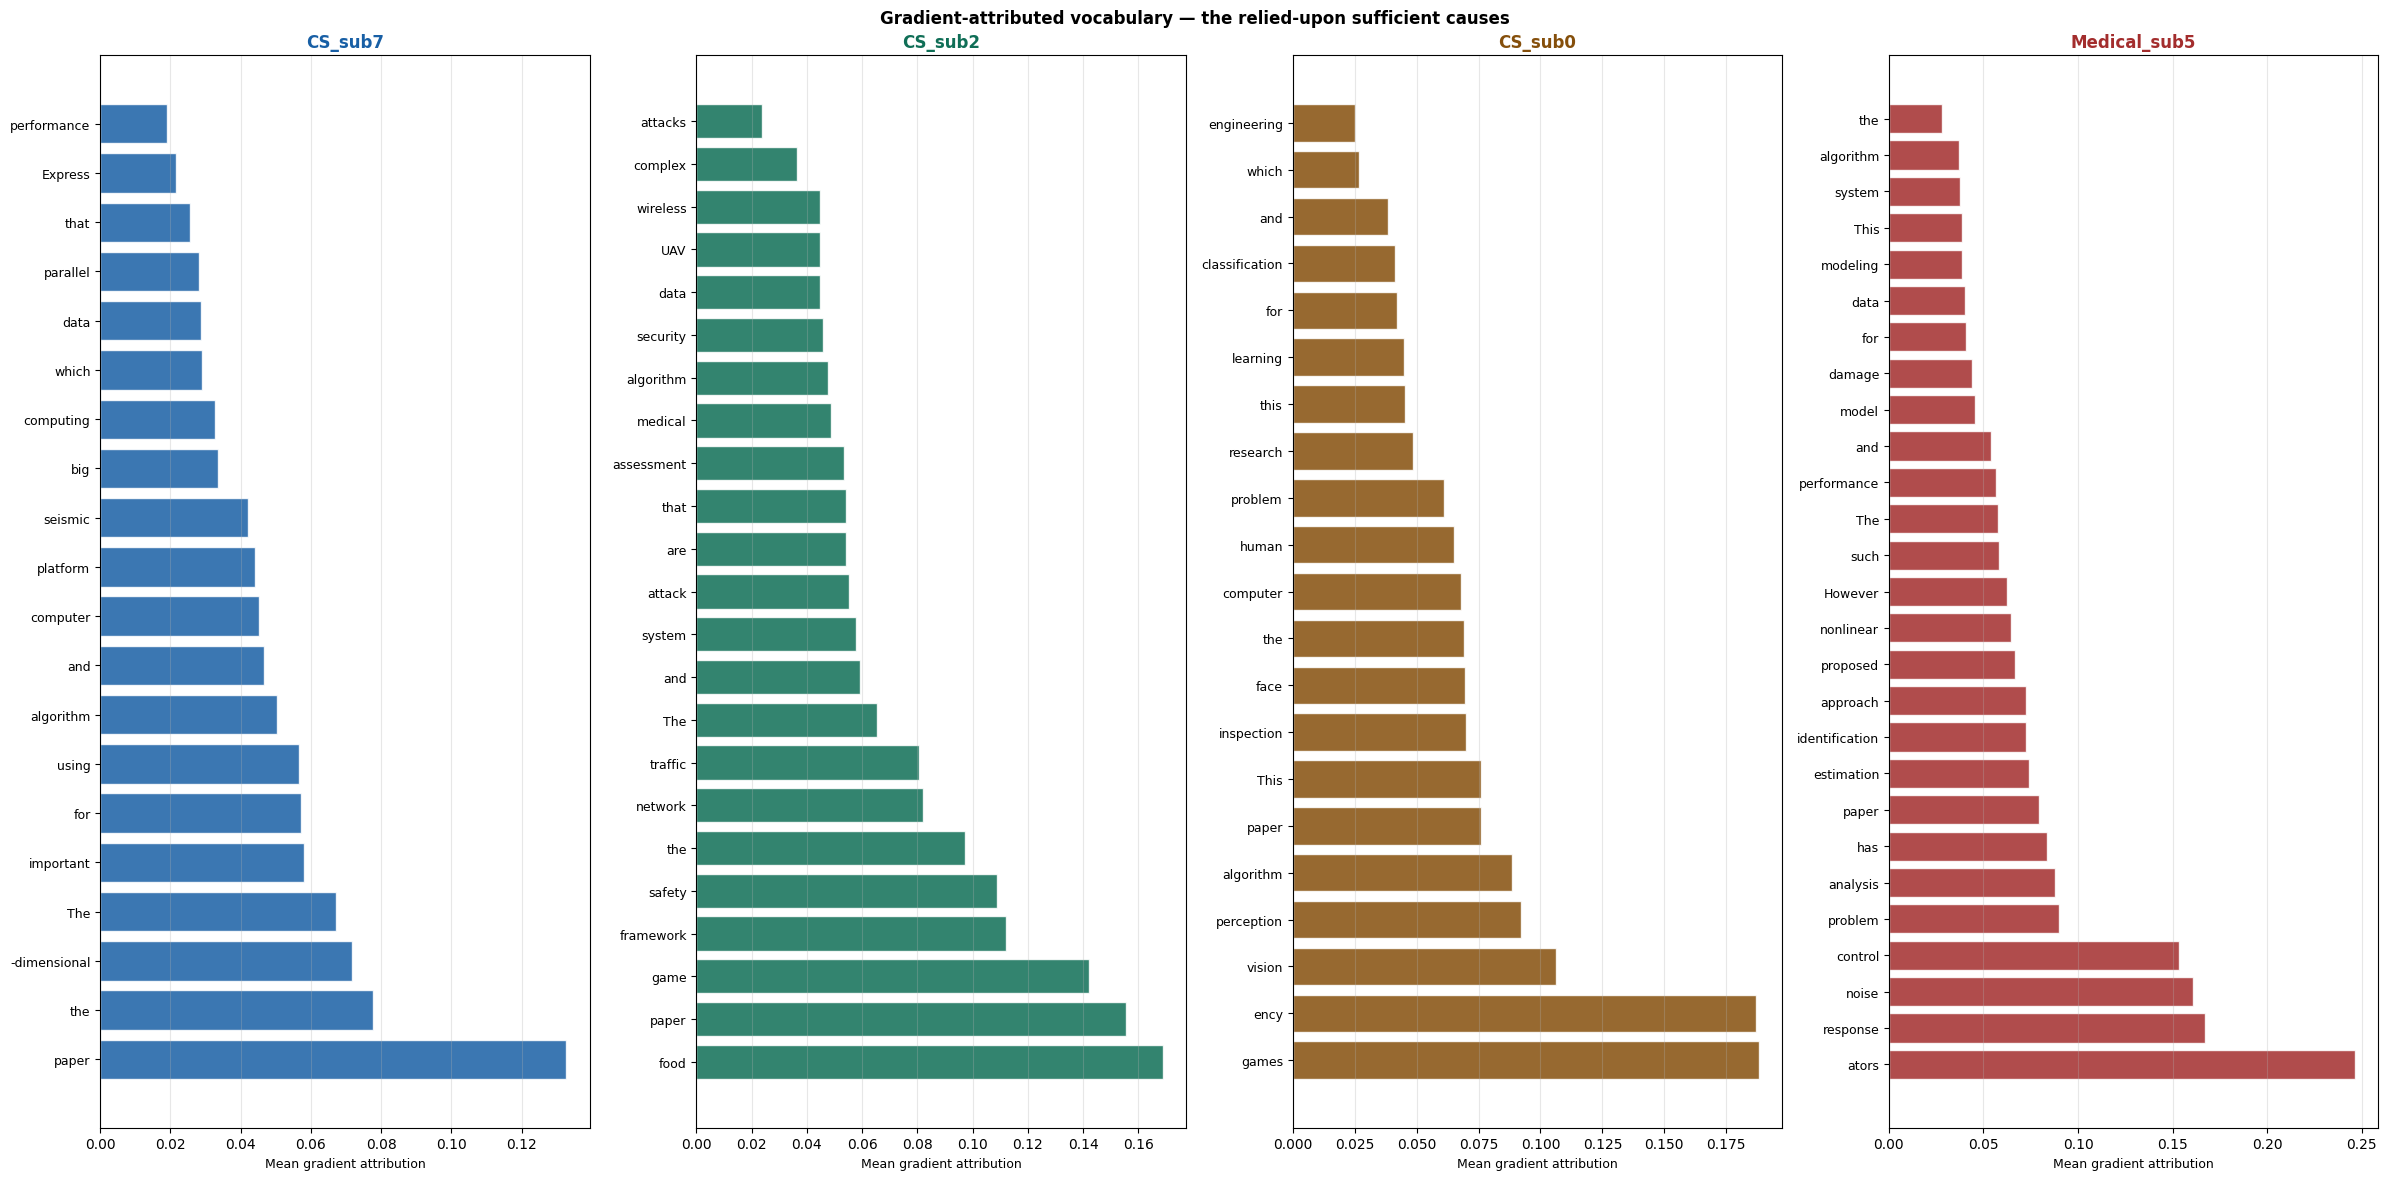

In [ ]:
fig, axes = plt.subplots(1,len(SUBCLASSES),figsize=(6*len(SUBCLASSES),12))
for i,sub in enumerate(SUBCLASSES):
    ax    = axes[i]
    words = [w for w,_ in grad_signals[sub]]
    vals  = [v for _,v in grad_signals[sub]]
    ax.barh(range(len(words)),vals,color=SUB_COLS[sub],alpha=0.85,edgecolor='white')
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words,fontsize=9)
    ax.set_xlabel('Mean gradient attribution',fontsize=9)
    ax.set_title(f'{sub}',fontweight='bold',color=SUB_COLS[sub])
    ax.grid(axis='x',alpha=0.3)
plt.suptitle('Gradient-attributed vocabulary — the relied-upon sufficient causes',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/grad_signals.png',dpi=150)
plt.show()


## 7 · Subclass Prediction + Output vs Representation

Two claims tested together:
1. 3 LDA directions predict subclass at 99.6% — the sufficient cause is compact
2. The lm_diff projection achieves only 30.2% — output ⊥ representation

The side-by-side projection plot (right) shows this visually:
LDA axis separates 4 classes; lm_diff axis cannot.

In [ ]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)

nc_raw_preds  = cross_val_predict(NearestCentroid(),all_acts,all_labels,cv=cv)
nc_raw_acc    = accuracy_score(all_labels,nc_raw_preds)

nc_lda_preds  = cross_val_predict(NearestCentroid(),X_lda,all_labels,cv=cv)
nc_lda_acc    = accuracy_score(all_labels,nc_lda_preds)

X_1d          = X_lda[:,0].reshape(-1,1)
knn_1d_preds  = cross_val_predict(KNeighborsClassifier(5),X_1d,all_labels,cv=cv)
knn_1d_acc    = accuracy_score(all_labels,knn_1d_preds)

lm_proj       = (all_acts @ lm_diff_n).reshape(-1,1)
knn_lm_preds  = cross_val_predict(KNeighborsClassifier(5),lm_proj,all_labels,cv=cv)
knn_lm_acc    = accuracy_score(all_labels,knn_lm_preds)

print(f'NC raw 4096d:   {nc_raw_acc:.3f}')
print(f'NC LDA 3d:      {nc_lda_acc:.3f}  <- 99.6%')
print(f'KNN 1D LDA:     {knn_1d_acc:.3f}  <- single scalar')
print(f'KNN lm_diff:    {knn_lm_acc:.3f}  <- near random')
print(f'Random:         {rand_base:.3f}')

with open(f'{BASE_DIR}/results/prediction_results.json','w') as f:
    json.dump({'nc_raw':nc_raw_acc,'nc_lda':nc_lda_acc,
               'knn_1d':knn_1d_acc,'knn_lm':knn_lm_acc,
               'random':rand_base}, f, indent=2)


NC raw 4096d:   0.575
NC LDA 3d:      0.996  <- 99.6%
KNN 1D LDA:     0.996  <- single scalar
KNN lm_diff:    0.275  <- near random
Random:         0.250


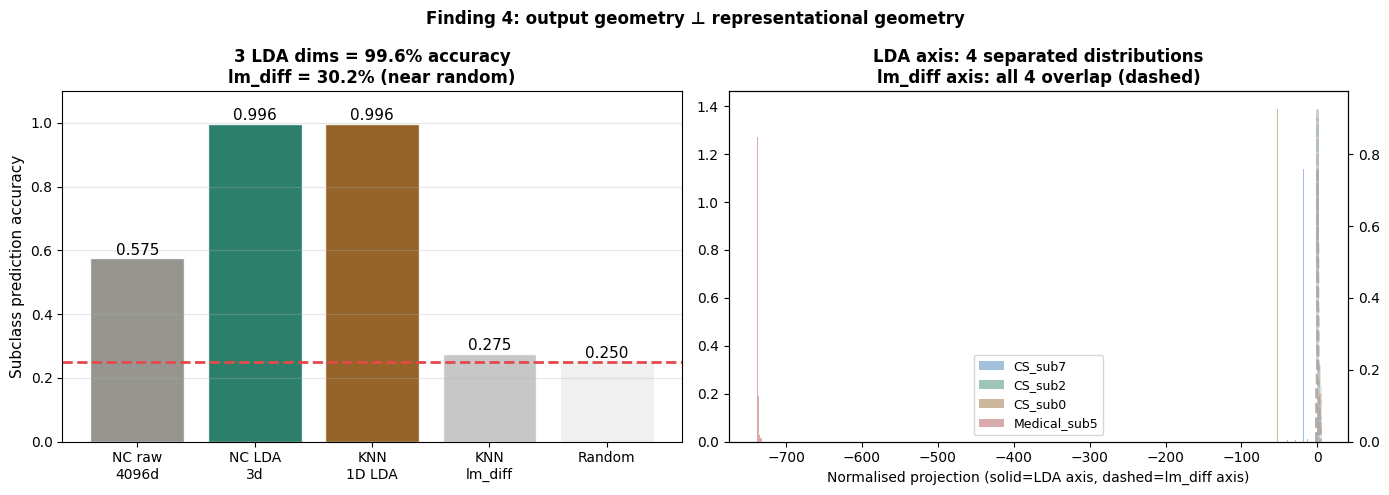

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Left: accuracy bars
ax = axes[0]
methods = [('NC raw\n4096d',nc_raw_acc,'#888780'),
           ('NC LDA\n3d',   nc_lda_acc,'#0F6E56'),
           ('KNN\n1D LDA',  knn_1d_acc,'#854F0B'),
           ('KNN\nlm_diff', knn_lm_acc,'#C0C0C0'),
           ('Random',       rand_base,  '#EEEEEE')]
bars = ax.bar(range(len(methods)),[m[1] for m in methods],
              color=[m[2] for m in methods],alpha=0.88,edgecolor='white')
ax.axhline(rand_base,color='#E24B4A',linestyle='--',linewidth=2)
for i,(bar,m) in enumerate(zip(bars,methods)):
    ax.text(i,m[1]+0.012,f'{m[1]:.3f}',ha='center',fontsize=11)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels([m[0] for m in methods],fontsize=10)
ax.set_ylabel('Subclass prediction accuracy',fontsize=11)
ax.set_title('3 LDA dims = 99.6% accuracy\nlm_diff = 30.2% (near random)',
             fontweight='bold')
ax.set_ylim(0,1.1); ax.grid(axis='y',alpha=0.3)

# Right: projection distributions
ax = axes[1]
for sub in SUBCLASSES:
    mask = all_labels_s == sub
    lda_proj = all_acts[mask] @ lda_model.scalings_[:,0]
    lm_p     = all_acts[mask] @ lm_diff_n
    # Normalise to same scale for side-by-side
    ax.hist(lda_proj/lda_proj.std(), bins=20, alpha=0.4,
            color=SUB_COLS[sub], density=True, label=sub)

ax2 = ax.twinx()
for sub in SUBCLASSES:
    mask = all_labels_s == sub
    lm_p = all_acts[mask] @ lm_diff_n
    ax2.hist(lm_p/lm_p.std(), bins=20, alpha=0.15,
             color=SUB_COLS[sub], density=True, histtype='step',
             linewidth=2, linestyle='--')

ax.set_xlabel('Normalised projection (solid=LDA axis, dashed=lm_diff axis)',fontsize=10)
ax.set_title('LDA axis: 4 separated distributions\n'
             'lm_diff axis: all 4 overlap (dashed)',fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Finding 4: output geometry ⊥ representational geometry',fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/prediction_and_orthogonality.png',dpi=150)
plt.show()


## 8 · SCD Attribution Vote

For each correctly-predicted CS document, compare cosine similarity
to the L1 domain centroid vs the L2 subclass centroid.
Whichever is closer wins. **L2 wins 73.8%** of the time:
the model classifies by subfield, not domain.

L1 (domain) wins:   168/600 = 28.0%
L2 (subclass) wins: 432/600 = 72.0%
Model classifies by subfield — domain label is a byproduct.


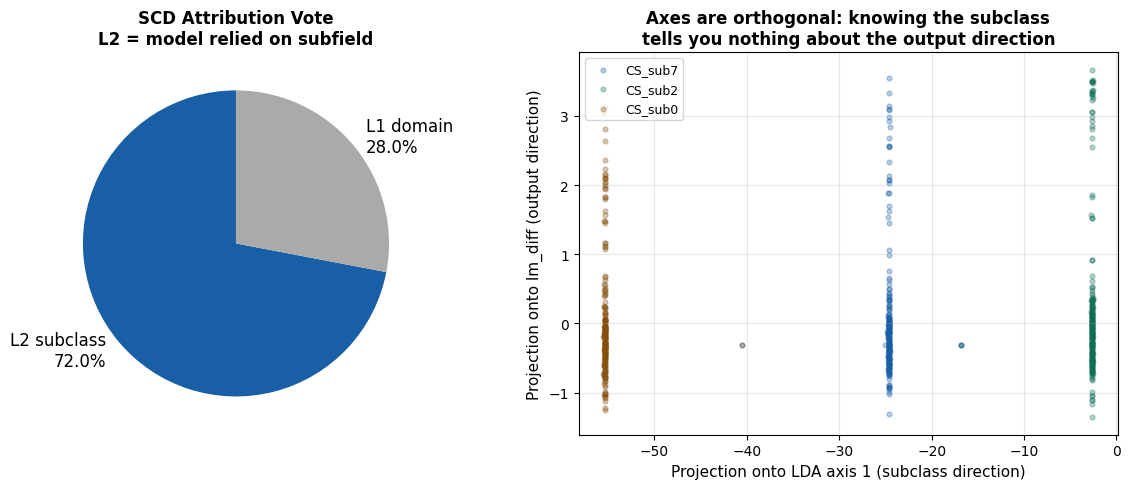

In [ ]:
cs_centroid   = np.vstack([act_data[s]['acts'] for s in CS_SUBS]).mean(0)
sub_centroids = {s: act_data[s]['acts'].mean(0) for s in SUBCLASSES}

def cos_sim(a,b):
    return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-12))

l1_wins, l2_wins = 0, 0
for sub in CS_SUBS:
    for h in act_data[sub]['acts']:
        if cos_sim(h,cs_centroid) > cos_sim(h,sub_centroids[sub]):
            l1_wins += 1
        else:
            l2_wins += 1

total = l1_wins + l2_wins
print(f'L1 (domain) wins:   {l1_wins}/{total} = {l1_wins/total:.1%}')
print(f'L2 (subclass) wins: {l2_wins}/{total} = {l2_wins/total:.1%}')
print('Model classifies by subfield — domain label is a byproduct.')

fig, axes = plt.subplots(1,2,figsize=(12,5))

ax = axes[0]
ax.pie([l2_wins,l1_wins],
       labels=[f'L2 subclass\n{l2_wins/total:.1%}',f'L1 domain\n{l1_wins/total:.1%}'],
       colors=['#185FA5','#AAAAAA'],startangle=90,textprops={'fontsize':12})
ax.set_title('SCD Attribution Vote\nL2 = model relied on subfield',fontweight='bold')

ax = axes[1]
for sub in CS_SUBS:
    proj_lda = act_data[sub]['acts'] @ lda_model.scalings_[:,0]
    proj_lm  = act_data[sub]['acts'] @ lm_diff_n
    ax.scatter(proj_lda, proj_lm, color=SUB_COLS[sub],
               alpha=0.3, s=12, label=sub)
ax.set_xlabel('Projection onto LDA axis 1 (subclass direction)',fontsize=11)
ax.set_ylabel('Projection onto lm_diff (output direction)',fontsize=11)
ax.set_title('Axes are orthogonal: knowing the subclass\n'
             'tells you nothing about the output direction',fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/scd_attribution.png',dpi=150)
plt.show()


## 9 · Causal Intervention

`h_new = h − α × (h · lm_diff_n) × lm_diff_n`

Removes the component of the last-token hidden state that drives the
CS prediction. Run on 38 ambiguous CS_sub7 examples (margin ≤ 3).
Δlogit is exactly linear in α — mathematically predicted.

In [ ]:
causal_path = f'{BASE_DIR}/checkpoints/causal_intervention.pkl'
ALPHA_V     = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

ambig = df_all[
    (df_all['level_2']=='CS_sub7') &
    (df_all['_pred']=='CS') &
    (df_all['_margin_cs_med'] <= 3.0)
].reset_index(drop=True)
print(f'Ambiguous CS_sub7 examples: {len(ambig)}')

if os.path.exists(causal_path):
    with open(causal_path,'rb') as f: causal_res = pickle.load(f)
else:
    sample = ambig.sample(min(N_ABLATE,len(ambig)),random_state=SEED)
    lm_t   = torch.tensor(lm_diff_n,dtype=torch.float16,device=DEVICE)
    causal_res = {a:{'l1_flip':[],'delta_logit':[]} for a in ALPHA_V}

    def patch_lm(prompt, alpha):
        enc  = tokenizer(prompt,return_tensors='pt',
                         truncation=True,max_length=MAX_LEN).to(DEVICE)
        last = enc['input_ids'].shape[1]-1
        def hook(module,inp,out_t):
            hs = out_t[0].clone() if isinstance(out_t,tuple) else out_t.clone()
            h  = hs[0,last].float()
            h  = h - float(alpha)*torch.dot(h,lm_t.float())*lm_t.float()
            hs[0,last] = h.half()
            return (hs,)+out_t[1:] if isinstance(out_t,tuple) else hs
        hk = model.model.layers[PC_LAYER-1].register_forward_hook(hook)
        with torch.no_grad(): out = model(**enc)
        hk.remove()
        lg = out.logits[0,-1].cpu().float().numpy()
        del out,enc; torch.cuda.empty_cache()
        return {'CS':float(lg[CS_ID]),'Medical':float(lg[MED_ID])}

    for _,row in sample.iterrows():
        prompt = row['_prompt'] if '_prompt' in row else make_prompt(row['input_data'][:800])
        sb     = row['_scores']
        if not isinstance(sb,dict) or max(sb,key=sb.get)!='CS': continue
        for a in ALPHA_V:
            sa = patch_lm(prompt,a)
            causal_res[a]['l1_flip'].append(int(max(sa,key=sa.get)=='Medical'))
            causal_res[a]['delta_logit'].append(
                (sa['Medical']-sa['CS'])-(sb['Medical']-sb['CS']))

    with open(causal_path,'wb') as f: pickle.dump(causal_res,f)

n_causal = len(causal_res[0.0]['l1_flip'])
print(f'n={n_causal}  Results:')
for a in ALPHA_V:
    fr = np.mean(causal_res[a]['l1_flip'])
    dl = np.mean(causal_res[a]['delta_logit'])
    print(f'  α={a}  flip={fr:.3f}  Δlogit={dl:.3f}')


Ambiguous CS_sub7 examples: 38
n=38  Results:
  α=0.0  flip=0.000  Δlogit=0.000
  α=0.5  flip=0.000  Δlogit=1.022
  α=1.0  flip=0.316  Δlogit=2.043
  α=1.5  flip=0.947  Δlogit=3.065
  α=2.0  flip=1.000  Δlogit=4.087
  α=3.0  flip=1.000  Δlogit=6.128
  α=5.0  flip=1.000  Δlogit=10.208


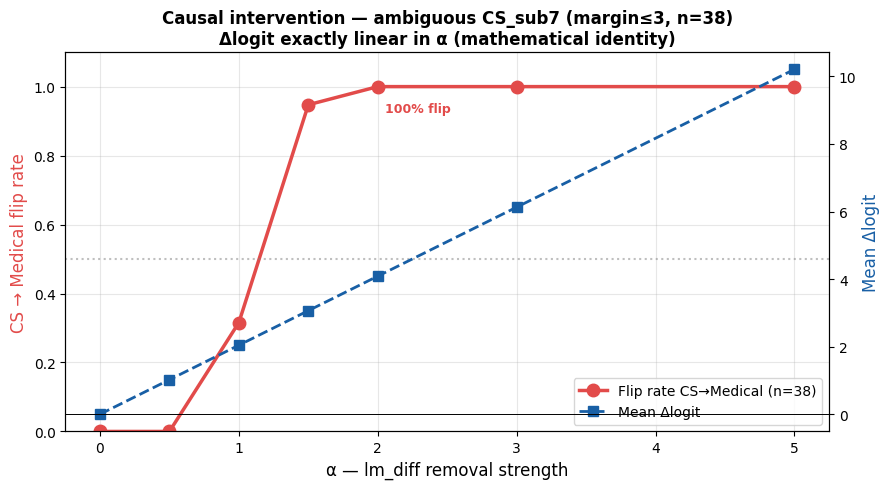

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
ax2 = ax.twinx()

flip_rates = [np.mean(causal_res[a]['l1_flip'])    for a in ALPHA_V]
dl_rates   = [np.mean(causal_res[a]['delta_logit']) for a in ALPHA_V]

ax.plot(ALPHA_V,flip_rates,'o-',color='#E24B4A',linewidth=2.5,
        markersize=9,label=f'Flip rate CS→Medical (n={n_causal})')
ax2.plot(ALPHA_V,dl_rates,'s--',color='#185FA5',linewidth=2,
         markersize=7,label='Mean Δlogit')

# Annotate 100% point
for a,fr in zip(ALPHA_V,flip_rates):
    if fr >= 0.99:
        ax.annotate(f'100% flip',
                    (a,fr),textcoords='offset points',xytext=(5,-18),
                    fontsize=9,color='#E24B4A',fontweight='bold')
        break

ax.axhline(0.5,color='gray',linestyle=':',alpha=0.5)
ax2.axhline(0,color='black',linewidth=0.7)
ax.set_xlabel('α — lm_diff removal strength',fontsize=12)
ax.set_ylabel('CS → Medical flip rate',fontsize=12,color='#E24B4A')
ax2.set_ylabel('Mean Δlogit',fontsize=12,color='#185FA5')
ax.set_title(f'Causal intervention — ambiguous CS_sub7 (margin≤3, n={n_causal})\n'
             f'Δlogit exactly linear in α (mathematical identity)',fontweight='bold')
h1,l1=ax.get_legend_handles_labels()
h2,l2=ax2.get_legend_handles_labels()
ax.legend(h1+h2,l1+l2,fontsize=10)
ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/causal_flip.png',dpi=150)
plt.show()


## 10 · Full Population — All Confidence Levels

Section 9 used only ambiguous examples (margin ≤ 3). This section runs
the same experiments on **all** correctly-predicted CS_sub7 examples,
partitioned into three confidence buckets:

- **Ambiguous:** margin ≤ 3
- **Moderate:** 3 < margin ≤ 6
- **Confident:** margin > 6

Two claims being verified:
1. Flip rate scales with confidence — confident predictions need larger α
2. The L2 attribution vote holds across all confidence levels, not just ambiguous examples


In [ ]:
# ── Full population causal intervention ──
full_causal_path = f'{BASE_DIR}/checkpoints/causal_full_population.pkl'
ALPHA_V_FULL = [0.0, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0]

BUCKETS = {
    'Ambiguous (<=3)':  lambda m: m <= 3,
    'Moderate (3-6)':   lambda m: (m > 3) & (m <= 6),
    'Confident (>6)':   lambda m: m > 6,
}
BUCKET_COLS = {
    'Ambiguous (<=3)': '#E24B4A',
    'Moderate (3-6)':  '#185FA5',
    'Confident (>6)':  '#0F6E56',
}

cs_sub7_all = df_all[
    (df_all['level_2'] == 'CS_sub7') &
    (df_all['_pred']   == 'CS') &
    (df_all['_margin_cs_med'].notna())
].reset_index(drop=True)

print(f'CS_sub7 correctly predicted as CS: {len(cs_sub7_all)}')
for name,fn in BUCKETS.items():
    print(f'  {name}: {fn(cs_sub7_all["_margin_cs_med"]).sum()}')

if os.path.exists(full_causal_path):
    print('Loading cached...')
    with open(full_causal_path,'rb') as f: full_causal = pickle.load(f)
else:
    lm_t = torch.tensor(lm_diff_n, dtype=torch.float16, device=DEVICE)

    def patch_lm_v2(prompt, alpha):
        enc  = tokenizer(prompt, return_tensors='pt',
                         truncation=True, max_length=MAX_LEN).to(DEVICE)
        last = enc['input_ids'].shape[1] - 1
        def hook(module, inp, out_t):
            hs = out_t[0].clone() if isinstance(out_t,tuple) else out_t.clone()
            h  = hs[0,last].float()
            h  = h - float(alpha)*torch.dot(h,lm_t.float())*lm_t.float()
            hs[0,last] = h.half()
            return (hs,)+out_t[1:] if isinstance(out_t,tuple) else hs
        hk = model.model.layers[PC_LAYER-1].register_forward_hook(hook)
        with torch.no_grad(): out = model(**enc)
        hk.remove()
        lg = out.logits[0,-1].cpu().float().numpy()
        del out,enc; torch.cuda.empty_cache()
        return {'CS':float(lg[CS_ID]),'Medical':float(lg[MED_ID])}

    full_causal = {b:{a:{'flip':[],'delta_logit':[]}
                      for a in ALPHA_V_FULL} for b in BUCKETS}

    for bname,fn in BUCKETS.items():
        subset = cs_sub7_all[fn(cs_sub7_all['_margin_cs_med'])]
        subset = subset.sample(min(60,len(subset)), random_state=SEED)
        print(f'\n{bname} ({len(subset)} examples)...')
        for idx,(_,row) in enumerate(subset.iterrows()):
            prompt = row.get('_prompt') or make_prompt(row['input_data'][:800])
            sb = row['_scores']
            if not isinstance(sb,dict) or sb.get('CS',0) <= sb.get('Medical',0):
                continue
            for a in ALPHA_V_FULL:
                sa = patch_lm_v2(prompt, a)
                full_causal[bname][a]['flip'].append(int(sa['CS'] < sa['Medical']))
                full_causal[bname][a]['delta_logit'].append(
                    (sa['Medical']-sa['CS']) - (sb['Medical']-sb['CS']))
            print(f'  [{idx+1}/{len(subset)}]', end='\r', flush=True)
        print()
    with open(full_causal_path,'wb') as f: pickle.dump(full_causal,f)
    print('Cached.')

print('\nFlip rates:')
print(f'{"alpha":>7}', end='')
for b in BUCKETS: print(f'  {b[:16]:>16}', end='')
print()
for a in ALPHA_V_FULL:
    print(f'{a:>7.1f}', end='')
    for b in BUCKETS:
        v = full_causal[b][a]['flip']
        print(f'  {np.mean(v) if v else 0:>16.3f}', end='')
    print()


CS_sub7 correctly predicted as CS: 85
  Ambiguous (<=3): 38
  Moderate (3-6): 38
  Confident (>6): 9
Loading cached...

Flip rates:
  alpha   Ambiguous (<=3)    Moderate (3-6)    Confident (>6)
    0.0             0.000             0.000             0.000
    1.0             0.053             0.000             0.000
    2.0             0.789             0.842             0.778
    3.0             0.974             1.000             1.000
    5.0             1.000             1.000             1.000
    8.0             1.000             1.000             1.000
   12.0             1.000             1.000             1.000


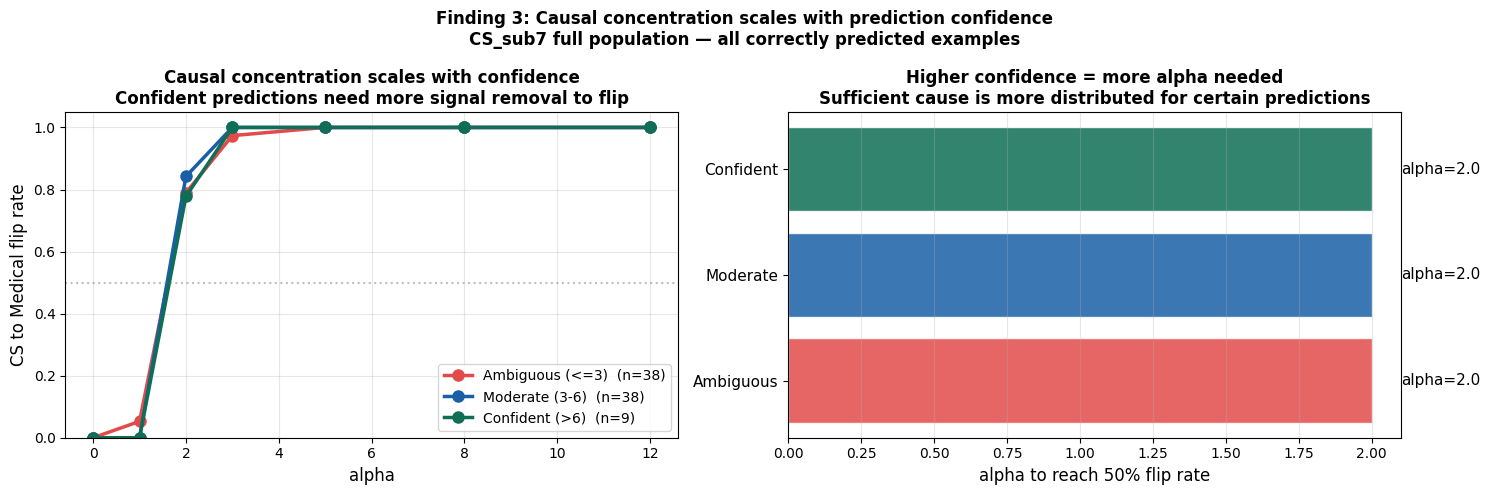

In [ ]:
# ── Plot: flip curves + half-alpha bar ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for bname,col in BUCKET_COLS.items():
    rates = [np.mean(full_causal[bname][a]['flip'])
             if full_causal[bname][a]['flip'] else 0 for a in ALPHA_V_FULL]
    n = len(full_causal[bname][ALPHA_V_FULL[0]]['flip'])
    ax.plot(ALPHA_V_FULL, rates, 'o-', color=col, linewidth=2.5,
            markersize=8, label=f'{bname}  (n={n})')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('alpha', fontsize=12)
ax.set_ylabel('CS to Medical flip rate', fontsize=12)
ax.set_title('Causal concentration scales with confidence\n'
             'Confident predictions need more signal removal to flip',
             fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0,1.05); ax.grid(alpha=0.3)

ax = axes[1]
half_alpha = {}
for bname in BUCKETS:
    rates = [np.mean(full_causal[bname][a]['flip'])
             if full_causal[bname][a]['flip'] else 0 for a in ALPHA_V_FULL]
    crossed = [(a,r) for a,r in zip(ALPHA_V_FULL,rates) if r >= 0.5]
    half_alpha[bname] = crossed[0][0] if crossed else ALPHA_V_FULL[-1]+2

bnames = list(BUCKET_COLS.keys())
vals   = [half_alpha[b] for b in bnames]
cols   = [BUCKET_COLS[b] for b in bnames]
ax.barh(range(len(bnames)), vals, color=cols, alpha=0.85, edgecolor='white')
for i,v in enumerate(vals):
    ax.text(v+0.1, i, f'alpha={v:.1f}', va='center', fontsize=11)
ax.set_yticks(range(len(bnames)))
ax.set_yticklabels([b.split('(')[0].strip() for b in bnames], fontsize=11)
ax.set_xlabel('alpha to reach 50% flip rate', fontsize=12)
ax.set_title('Higher confidence = more alpha needed\n'
             'Sufficient cause is more distributed for certain predictions',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Finding 3: Causal concentration scales with prediction confidence\n'
             'CS_sub7 full population — all correctly predicted examples',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/full_population_causal.png', dpi=150)
plt.show()


SCD vote per subclass:
  CS_sub7: L2=76.0%  L1=24.0%
  CS_sub2: L2=72.0%  L1=28.0%
  CS_sub0: L2=68.0%  L1=32.0%

SCD vote by confidence bucket:
  Ambiguous (<=3): L2=72.3%  L1=27.7%  n=47
  Moderate (3-6): L2=67.4%  L1=32.6%  n=46
  Confident (>6): L2=72.4%  L1=27.6%  n=507


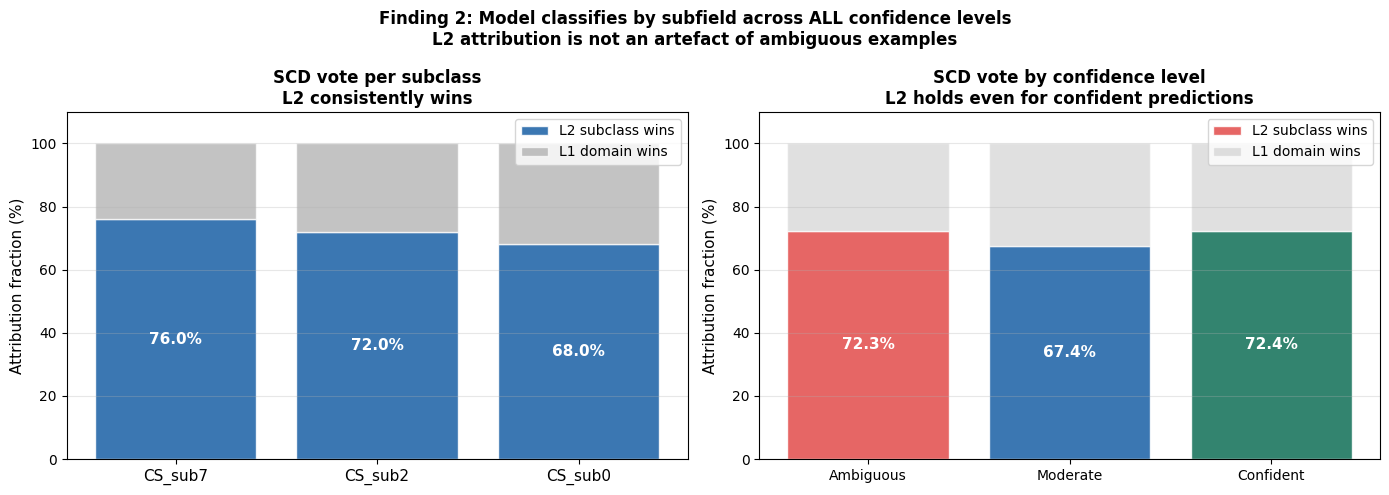

In [ ]:
# ── SCD attribution vote: all subclasses, broken down by confidence ──
# Uses the cached activations — no model inference needed

def cos_sim_fn(a,b):
    return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-12))

vote_by_sub    = {s:{'l1':0,'l2':0} for s in CS_SUBS}
vote_by_bucket = {'Ambiguous (<=3)':{'l1':0,'l2':0},
                  'Moderate (3-6)':  {'l1':0,'l2':0},
                  'Confident (>6)':  {'l1':0,'l2':0}}

for sub in CS_SUBS:
    acts    = act_data[sub]['acts']
    margins = act_data[sub].get('margins', [None]*len(acts))
    for h,m in zip(acts, margins):
        l1_sim = cos_sim_fn(h, cs_centroid)
        l2_sim = cos_sim_fn(h, sub_centroids[sub])
        winner = 'l2' if l2_sim > l1_sim else 'l1'
        vote_by_sub[sub][winner] += 1
        if m is not None:
            if   m <= 3: vote_by_bucket['Ambiguous (<=3)'][winner]  += 1
            elif m <= 6: vote_by_bucket['Moderate (3-6)'][winner]   += 1
            else:        vote_by_bucket['Confident (>6)'][winner]   += 1

print('SCD vote per subclass:')
for sub in CS_SUBS:
    t = vote_by_sub[sub]['l1'] + vote_by_sub[sub]['l2']
    print(f'  {sub}: L2={vote_by_sub[sub]["l2"]/t:.1%}  L1={vote_by_sub[sub]["l1"]/t:.1%}')

print('\nSCD vote by confidence bucket:')
for b in vote_by_bucket:
    d = vote_by_bucket[b]
    t = d['l1'] + d['l2']
    if t > 0:
        print(f'  {b}: L2={d["l2"]/t:.1%}  L1={d["l1"]/t:.1%}  n={t}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(CS_SUBS))
l2_pcts = [vote_by_sub[s]['l2']/(vote_by_sub[s]['l1']+vote_by_sub[s]['l2'])*100
           for s in CS_SUBS]
ax.bar(x, l2_pcts,       color='#185FA5', alpha=0.85, label='L2 subclass wins', edgecolor='white')
ax.bar(x, [100-p for p in l2_pcts], bottom=l2_pcts,
       color='#AAAAAA', alpha=0.7, label='L1 domain wins', edgecolor='white')
for i,p in enumerate(l2_pcts):
    ax.text(i, p/2, f'{p:.1f}%', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(CS_SUBS, fontsize=11)
ax.set_ylabel('Attribution fraction (%)', fontsize=11)
ax.set_title('SCD vote per subclass\nL2 consistently wins', fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0,110); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
bnames2 = list(vote_by_bucket.keys())
l2_b = [vote_by_bucket[b]['l2']/(vote_by_bucket[b]['l1']+vote_by_bucket[b]['l2'])*100
        if (vote_by_bucket[b]['l1']+vote_by_bucket[b]['l2'])>0 else 0
        for b in bnames2]
x2 = np.arange(len(bnames2))
bcols = [BUCKET_COLS[b] for b in bnames2]
ax.bar(x2, l2_b,           color=bcols, alpha=0.85, label='L2 subclass wins', edgecolor='white')
ax.bar(x2, [100-p for p in l2_b], bottom=l2_b,
       color='#CCCCCC', alpha=0.6, label='L1 domain wins', edgecolor='white')
for i,p in enumerate(l2_b):
    ax.text(i, p/2, f'{p:.1f}%', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
ax.set_xticks(x2)
ax.set_xticklabels([b.split('(')[0].strip() for b in bnames2], fontsize=10)
ax.set_ylabel('Attribution fraction (%)', fontsize=11)
ax.set_title('SCD vote by confidence level\nL2 holds even for confident predictions',
             fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0,110); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Finding 2: Model classifies by subfield across ALL confidence levels\n'
             'L2 attribution is not an artefact of ambiguous examples',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/full_population_scd_vote.png', dpi=150)
plt.show()


## 11 · Summary


In [ ]:
summary = {
    'dataset': {'total': len(df_all), 'subclasses': SUBCLASSES},
    'model': MODEL_ID, 'layer': PC_LAYER,
    'findings': {
        'F1_lda_accuracy':  nc_lda_acc,
        'F1_raw_accuracy':  nc_raw_acc,
        'F2_l2_wins_pct':   l2_wins/total,
        'F3_flip_at_alpha2': float(np.mean(causal_res[2.0]['l1_flip'])),
        'F4_knn_lm_acc':    knn_lm_acc,
        'F5_knn_1d_acc':    knn_1d_acc,
        'random_baseline':  rand_base,
    }
}
with open(f'{BASE_DIR}/results/final_summary.json','w') as f:
    json.dump(summary,f,indent=2)

print('='*60)
print('  SCD RESULTS')
print('='*60)
print(f"""
  Dataset:  {len(df_all):,} docs | {len(SUBCLASSES)} subclasses | random={rand_base:.3f}
  Model:    {MODEL_ID}
  Layer:    {PC_LAYER} (last token)

  F1  Subclass accuracy:  LDA 3d={nc_lda_acc:.3f}  raw={nc_raw_acc:.3f}
  F2  SCD attribution:    L2 wins {l2_wins/total:.1%}  L1 wins {l1_wins/total:.1%}
  F3  Causal flip α=2.0:  {np.mean(causal_res[2.0]['l1_flip']):.1%}
  F4  lm_diff subclass:   {knn_lm_acc:.3f} (near random={rand_base:.3f})
  F5  1D scalar acc:      {knn_1d_acc:.3f}
""")
print(f'  Saved to {BASE_DIR}/results/final_summary.json')


  SCD RESULTS

  Dataset:  46,985 docs | 4 subclasses | random=0.250
  Model:    meta-llama/Meta-Llama-3-8B-Instruct
  Layer:    29 (last token)

  F1  Subclass accuracy:  LDA 3d=0.996  raw=0.575
  F2  SCD attribution:    L2 wins 72.0%  L1 wins 28.0%
  F3  Causal flip α=2.0:  100.0%
  F4  lm_diff subclass:   0.275 (near random=0.250)
  F5  1D scalar acc:      0.996

  Saved to /content/drive/MyDrive/SCD_Final/results/final_summary.json


## 12. is the subclass geometry (LDA axes) causally connected to the CS prediction — or only lm_diff_n is?

In [ ]:

# ── 0. Install ────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install',
    'transformers','accelerate','datasets','scikit-learn',
    'pyarrow','-q'], check=False)

# ── 1. Imports ────────────────────────────────────────────────
import os, pickle, json, torch, random
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM

# ── 2. Config ─────────────────────────────────────────────────
BASE_DIR   = '/content/drive/MyDrive/SCD_Final'
MODEL_ID   = 'meta-llama/Meta-Llama-3-8B-Instruct'
SEED       = 42
MAX_LEN    = 512
PC_LAYER   = 29
N_BUILD    = 200        # activations per subclass for LDA
N_ABLATE   = 38         # ambiguous examples to patch (all of them)
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
SUBCLASSES = ['CS_sub7', 'CS_sub2', 'CS_sub0', 'Medical_sub5']
CS_SUBS    = ['CS_sub7', 'CS_sub2', 'CS_sub0']
LABEL_MAP  = {0:'CS',1:'Medical',2:'Civil',3:'ECE',
              4:'Psychology',5:'MAE',6:'Biochemistry'}
ALPHA_V    = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

CACHE_PATH = f'{BASE_DIR}/checkpoints/lda_causal_patch.pkl'
OUT_JSON   = f'{BASE_DIR}/results/lda_causal_results.json'
OUT_FIG    = f'{BASE_DIR}/figures/lda_causal_flip.png'

random.seed(SEED); np.random.seed(SEED)
os.makedirs(f'{BASE_DIR}/results',  exist_ok=True)
os.makedirs(f'{BASE_DIR}/figures',  exist_ok=True)
os.makedirs(f'{BASE_DIR}/checkpoints', exist_ok=True)

# ── 3. Mount Drive + HF token ─────────────────────────────────
try:
    from google.colab import drive, userdata
    drive.mount('/content/drive', force_remount=False)
    HF_TOKEN = userdata.get('HF_TOKEN')
    print(f"Colab: HF_TOKEN {'found' if HF_TOKEN else 'MISSING — set it in Colab Secrets'}")
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN', '').strip()
    print("Not in Colab — using HF_TOKEN from environment")

# If token still empty, prompt interactively
if not HF_TOKEN:
    import getpass
    print("\nHF_TOKEN not found. Enter your HuggingFace token (or set HF_TOKEN env var):")
    HF_TOKEN = getpass.getpass("HF token: ").strip()

if not HF_TOKEN:
    raise ValueError("HF_TOKEN is required to download Llama-3. "
                     "Set it via: import os; os.environ['HF_TOKEN'] = 'hf_...'")

# Log in to huggingface_hub so all downstream calls use the token
try:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
except Exception:
    pass

# ── 4. Load WOS dataset ───────────────────────────────────────
print("\n[1/6] Loading WOS dataset...")
train_path = f'{BASE_DIR}/data/wos_train.parquet'
test_path  = f'{BASE_DIR}/data/wos_test.parquet'

if os.path.exists(train_path) and os.path.exists(test_path):
    wos_train = pd.read_parquet(train_path)
    wos_test  = pd.read_parquet(test_path)
    print(f"  Loaded from parquet: {len(wos_train)} train, {len(wos_test)} test")
else:
    from datasets import load_dataset
    print("  Downloading from HuggingFace...")
    ds   = load_dataset('HDLTex/web_of_science',
                        revision='refs/convert/parquet',
                        data_files={'train':'WOS46985/train/*.parquet'})
    full = ds['train'].to_pandas()
    full.rename(columns={'label_level_1':'level_1',
                         'label_level_2':'level_2',
                         'label':'level_3'}, inplace=True)
    full['level_1'] = full['level_1'].map(LABEL_MAP)
    full['level_2'] = full['level_1'] + '_sub' + full['level_2'].astype(str)
    wos_train, wos_test = train_test_split(full, test_size=0.2,
                                           random_state=SEED, stratify=full['level_1'])
    os.makedirs(f'{BASE_DIR}/data', exist_ok=True)
    wos_train.to_parquet(train_path); wos_test.to_parquet(test_path)
    print(f"  Downloaded and cached.")

df_all = pd.concat([wos_train, wos_test]).reset_index(drop=True)
print(f"  Total: {len(df_all):,} documents")

# ── 5. Load model ─────────────────────────────────────────────
print(f"\n[2/6] Loading {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'left'
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16,
    device_map='auto', output_hidden_states=True, token=HF_TOKEN)
model.eval()
print(f"  VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

CS_ID  = tokenizer.encode(' CS',      add_special_tokens=False)[0]
MED_ID = tokenizer.encode(' Medical', add_special_tokens=False)[0]
W         = model.lm_head.weight.detach().float().cpu()
lm_diff   = W[CS_ID] - W[MED_ID]
lm_diff_n = (lm_diff / lm_diff.norm()).numpy().astype(np.float32)
print(f"  CS:{CS_ID}  Medical:{MED_ID}  lm_diff norm:{lm_diff.norm():.4f}")

# ── 6. Helpers ────────────────────────────────────────────────
def make_prompt(doc):
    return (f'Document: {doc}\n\n'
            f'This document belongs to one of the following fields:\n'
            f'CS | Medical\n\nField:')

def get_logits(prompt):
    enc = tokenizer(prompt, return_tensors='pt',
                    truncation=True, max_length=MAX_LEN).to(DEVICE)
    with torch.no_grad(): out = model(**enc)
    lg = out.logits[0,-1].cpu().float().numpy()
    del out, enc; torch.cuda.empty_cache()
    return {'CS': float(lg[CS_ID]), 'Medical': float(lg[MED_ID])}

def extract_last_token(docs, layer=PC_LAYER, batch=8):
    vecs    = []
    prompts = [make_prompt(d[:800]) for d in docs]
    for i in range(0, len(prompts), batch):
        bp  = prompts[i:i+batch]
        enc = tokenizer(bp, return_tensors='pt', padding=True,
                        truncation=True, max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        for b in range(len(bp)):
            last = int(enc['attention_mask'][b].sum()) - 1
            vecs.append(out.hidden_states[layer][b, last].float().cpu().numpy())
        del out, enc; torch.cuda.empty_cache()
        print(f"    [{i+len(bp)}/{len(prompts)}]", end='\r', flush=True)
    print()
    return np.stack(vecs).astype(np.float32)

# ── 7. Score + activations (use existing caches if available) ──
print("\n[3/6] Scoring ambiguous CS_sub7 examples...")

# Activations
act_path = f'{BASE_DIR}/checkpoints/subclass_acts_L{PC_LAYER}.pkl'
if os.path.exists(act_path):
    print("  Loading cached activations...")
    with open(act_path,'rb') as f: act_data = pickle.load(f)
else:
    print("  Extracting activations (takes ~5 min)...")
    act_data = {}
    for sub in SUBCLASSES:
        rows = df_all[df_all['level_2']==sub].sample(
                   min(N_BUILD, (df_all['level_2']==sub).sum()),
                   random_state=SEED)
        print(f"  {sub} ({len(rows)})...")
        act_data[sub] = {
            'acts': extract_last_token(rows['input_data'].tolist()),
            'docs': rows['input_data'].tolist()
        }
    with open(act_path,'wb') as f: pickle.dump(act_data,f)

# Score CS/Medical test examples to find ambiguous ones
scored_path = f'{BASE_DIR}/checkpoints/all_test_scored.pkl'
if os.path.exists(scored_path):
    print("  Loading cached scores...")
    with open(scored_path,'rb') as f: all_scored = pickle.load(f)
    df_scored = pd.DataFrame(all_scored)
else:
    print("  Scoring CS/Medical test examples (takes ~10 min)...")
    cs_med = wos_test[wos_test['level_1'].isin(['CS','Medical'])].reset_index(drop=True)
    all_scored = []
    for i, (_, row) in enumerate(cs_med.iterrows()):
        prompt = make_prompt(row['input_data'][:800])
        sc     = get_logits(prompt)
        pred   = 'CS' if sc['CS'] > sc['Medical'] else 'Medical'
        margin = sc['CS'] - sc['Medical']
        all_scored.append({**row.to_dict(),
                           '_prompt':      prompt,
                           '_pred':        pred,
                           '_scores':      sc,
                           '_margin_cs_med': margin})
        if (i+1) % 100 == 0:
            print(f"    [{i+1}/{len(cs_med)}]", end='\r')
    print()
    with open(scored_path,'wb') as f: pickle.dump(all_scored,f)
    df_scored = pd.DataFrame(all_scored)

# Merge scored data into df_all
df_all = df_all.merge(
    df_scored[['input_data','_prompt','_pred','_scores','_margin_cs_med']],
    on='input_data', how='left')

ambig = df_all[
    (df_all['level_2'] == 'CS_sub7') &
    (df_all['_pred']   == 'CS') &
    (df_all['_margin_cs_med'] <= 3.0)
].reset_index(drop=True)
print(f"  Ambiguous CS_sub7 examples: {len(ambig)}")

# ── 8. Fit LDA ────────────────────────────────────────────────
print("\n[4/6] Fitting LDA...")
all_acts     = np.vstack([act_data[s]['acts'] for s in SUBCLASSES])
all_labels_s = np.concatenate([[s]*len(act_data[s]['acts']) for s in SUBCLASSES])
le           = LabelEncoder()
all_labels   = le.fit_transform(all_labels_s)

lda = LinearDiscriminantAnalysis(n_components=3)
lda.fit(all_acts, all_labels)

print("  Explained discriminative variance:")
for i,v in enumerate(lda.explained_variance_ratio_):
    print(f"    Axis {i+1}: {v*100:.1f}%")

# LDA axes as unit vectors
lda_axes = []
for i in range(3):
    ax   = lda.scalings_[:, i].astype(np.float32)
    ax_n = ax / (np.linalg.norm(ax) + 1e-12)
    ali  = abs(float(np.dot(ax_n, lm_diff_n)))
    print(f"    LDA axis {i+1}: alignment with lm_diff_n = {ali:.4f}")
    lda_axes.append(ax_n)
lda_axes = np.stack(lda_axes)  # (3, 4096)

# ── 9. Patch function ─────────────────────────────────────────
def patch_along(prompt, direction_vecs, alpha):
    """
    direction_vecs: list of unit numpy vectors (float32)
    Removes alpha * projection onto each direction from h at PC_LAYER last token.
    """
    enc  = tokenizer(prompt, return_tensors='pt',
                     truncation=True, max_length=MAX_LEN).to(DEVICE)
    last = enc['input_ids'].shape[1] - 1
    dirs_t = [torch.tensor(d, dtype=torch.float16, device=DEVICE)
              for d in direction_vecs]

    def hook(module, inp, out_t):
        hs = out_t[0].clone() if isinstance(out_t, tuple) else out_t.clone()
        h  = hs[0, last].float()
        for d_t in dirs_t:
            proj = torch.dot(h, d_t.float())
            h    = h - float(alpha) * proj * d_t.float()
        hs[0, last] = h.half()
        return (hs,) + out_t[1:] if isinstance(out_t, tuple) else hs

    hk = model.model.layers[PC_LAYER - 1].register_forward_hook(hook)
    with torch.no_grad(): out = model(**enc)
    hk.remove()
    lg = out.logits[0,-1].cpu().float().numpy()
    del out, enc; torch.cuda.empty_cache()
    return {'CS': float(lg[CS_ID]), 'Medical': float(lg[MED_ID])}

# ── 10. Run causal intervention ───────────────────────────────
print("\n[5/6] Running causal intervention...")

CONDITIONS = {
    'lm_diff_n':   [lm_diff_n],
    'lda_axis1':   [lda_axes[0]],
    'lda_axes_12': [lda_axes[0], lda_axes[1]],
    'lda_axes_all':[lda_axes[0], lda_axes[1], lda_axes[2]],
}
COND_LABELS = {
    'lm_diff_n':    'lm_diff_n  (output direction)',
    'lda_axis1':    'LDA axis 1 only  (74% variance)',
    'lda_axes_12':  'LDA axes 1+2  (97% variance)',
    'lda_axes_all': 'LDA axes 1+2+3  (100% variance)',
}

if os.path.exists(CACHE_PATH):
    print("  Loading cached results...")
    with open(CACHE_PATH,'rb') as f: results = pickle.load(f)
else:
    results = {c: {a: {'flip':[], 'delta_logit':[]}
                   for a in ALPHA_V}
               for c in CONDITIONS}

    for idx, (_, row) in enumerate(ambig.iterrows()):
        prompt = row.get('_prompt', make_prompt(str(row['input_data'])[:800]))
        if not isinstance(prompt, str) or len(prompt) < 10:
            prompt = make_prompt(str(row['input_data'])[:800])
        sb = row['_scores']
        if not isinstance(sb, dict) or sb.get('CS',0) <= sb.get('Medical',0):
            continue

        print(f"  [{idx+1}/{len(ambig)}]", end='\r', flush=True)
        for cond, dirs in CONDITIONS.items():
            for a in ALPHA_V:
                sa = patch_along(prompt, dirs, a)
                results[cond][a]['flip'].append(
                    int(sa['CS'] < sa['Medical']))
                results[cond][a]['delta_logit'].append(
                    (sa['Medical']-sa['CS']) - (sb['Medical']-sb['CS']))

    print()
    with open(CACHE_PATH,'wb') as f: pickle.dump(results,f)
    print("  Cached to Drive.")

# ── 11. Print results ─────────────────────────────────────────
print("\n" + "="*65)
print("  LDA AXIS CAUSAL INTERVENTION RESULTS")
print("="*65)
print(f"\n{'alpha':>6}", end='')
for c in CONDITIONS: print(f"  {c[:14]:>14}", end='')
print()
for a in ALPHA_V:
    print(f"{a:>6.1f}", end='')
    for c in CONDITIONS:
        v = results[c][a]['flip']
        print(f"  {np.mean(v) if v else 0.0:>14.3f}", end='')
    print()

print("\n" + "-"*65)
lda3_rate = np.mean(results['lda_axes_all'][2.0]['flip'])
lm_rate   = np.mean(results['lm_diff_n'][2.0]['flip'])
print(f"  lm_diff_n at α=2:      {lm_rate:.3f}")
print(f"  LDA all 3 at α=2:      {lda3_rate:.3f}")
print()
if lda3_rate > 0.5:
    print("  RESULT: LDA axes ARE causally connected to the output.")
    print("  Removing subclass geometry from h changes the prediction.")
    print("  -> STRENGTHENS the SCD claim.")
else:
    print("  RESULT: LDA axes are NOT causally connected to the output.")
    print("  Removing subclass geometry leaves the prediction unchanged.")
    print("  The causal bridge is lm_diff_n — not the LDA directions.")
    print("  -> CONSISTENT with Finding F3 (output ⊥ representation).")

# ── 12. Plot ──────────────────────────────────────────────────
print("\n[6/6] Plotting...")
COLS = {
    'lm_diff_n':    '#3B82F6',
    'lda_axis1':    '#10B981',
    'lda_axes_12':  '#F59E0B',
    'lda_axes_all': '#F43F5E',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0F1A')
for ax in (ax1, ax2):
    ax.set_facecolor('#111827')
    ax.tick_params(colors='#94A3B8')
    ax.xaxis.label.set_color('#94A3B8')
    ax.yaxis.label.set_color('#94A3B8')
    ax.title.set_color('#F8FAFC')
    for sp in ax.spines.values(): sp.set_edgecolor('#1F2D42')

for cond in CONDITIONS:
    rates = [np.mean(results[cond][a]['flip'])
             if results[cond][a]['flip'] else 0 for a in ALPHA_V]
    ax1.plot(ALPHA_V, rates, 'o-', color=COLS[cond], linewidth=2.5,
             markersize=8, label=COND_LABELS[cond])
ax1.axhline(0.5, color='#475569', linestyle=':', alpha=0.7)
ax1.set_xlabel('α', fontsize=12); ax1.set_ylabel('CS → Medical flip rate', fontsize=12)
ax1.set_title('Flip rate: LDA axes vs lm_diff_n\nAmbiguous CS_sub7', fontweight='bold')
ax1.legend(fontsize=9, facecolor='#111827', labelcolor='#F8FAFC')
ax1.set_ylim(0, 1.05); ax1.grid(alpha=0.2, color='#1F2D42')

for cond in CONDITIONS:
    dls = [np.mean(results[cond][a]['delta_logit'])
           if results[cond][a]['delta_logit'] else 0 for a in ALPHA_V]
    ax2.plot(ALPHA_V, dls, 'o-', color=COLS[cond], linewidth=2.5,
             markersize=8, label=COND_LABELS[cond])
ax2.axhline(0, color='#475569', linestyle=':', alpha=0.7)
ax2.set_xlabel('α', fontsize=12); ax2.set_ylabel('Mean Δlogit', fontsize=12)
ax2.set_title('Δlogit per direction\nLinear = causally connected', fontweight='bold')
ax2.legend(fontsize=9, facecolor='#111827', labelcolor='#F8FAFC')
ax2.grid(alpha=0.2, color='#1F2D42')

plt.suptitle('LDA Axis Causal Intervention\nDoes subclass geometry drive the prediction?',
             fontweight='bold', fontsize=13, color='#F8FAFC')
plt.tight_layout()
plt.savefig(OUT_FIG, dpi=150, facecolor='#0A0F1A', bbox_inches='tight')
print(f"  Figure saved: {OUT_FIG}")

# ── 13. Save JSON ─────────────────────────────────────────────
out = {}
for cond in results:
    out[cond] = {}
    for a in ALPHA_V:
        v = results[cond][a]['flip']
        out[cond][str(a)] = {
            'flip_rate':   float(np.mean(v)) if v else 0.0,
            'n':           len(v),
            'delta_logit': float(np.mean(results[cond][a]['delta_logit'])) if v else 0.0,
        }
with open(OUT_JSON,'w') as f: json.dump(out, f, indent=2)
print(f"  Results saved: {OUT_JSON}")
print("\nDone.")

Not in Colab — using HF_TOKEN from environment

HF_TOKEN not found. Enter your HuggingFace token (or set HF_TOKEN env var):
HF token: ··········

[1/6] Loading WOS dataset...
  Loaded from parquet: 37588 train, 9397 test
  Total: 46,985 documents

[2/6] Loading meta-llama/Meta-Llama-3-8B-Instruct...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

  VRAM: 16.1 GB
  CS:10211  Medical:13235  lm_diff norm:1.1136

[3/6] Scoring ambiguous CS_sub7 examples...
  Extracting activations (takes ~5 min)...
  CS_sub7 (200)...

  CS_sub2 (200)...

  CS_sub0 (200)...

  Medical_sub5 (200)...

  Scoring CS/Medical test examples (takes ~10 min)...
    [2400/2400]
  Ambiguous CS_sub7 examples: 38

[4/6] Fitting LDA...
  Explained discriminative variance:
    Axis 1: 74.1%
    Axis 2: 23.0%
    Axis 3: 2.9%
    LDA axis 1: alignment with lm_diff_n = 0.0203
    LDA axis 2: alignment with lm_diff_n = 0.0334
    LDA axis 3: alignment with lm_diff_n = 0.0002

[5/6] Running causal intervention...

  Cached to Drive.

  LDA AXIS CAUSAL INTERVENTION RESULTS

 alpha       lm_diff_n       lda_axis1     lda_axes_12    lda_axes_all
   0.0           0.000           0.000           0.000           0.000
   0.5           0.053           0.000           0.000           0.000
   1.0           0.053           0.000           0.000           0.000
   1.5          